In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from sklearn.linear_model import Lasso, LassoCV, LinearRegression
from sklearn.metrics import r2_score

### Feature correlation

C:\Users\mhwu9\AppData\Local\Temp\ipykernel_27376\1110618220.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['return_1day'] = df['AdjustedClose'].pct_change(1)


Correlation with Target:
SecuritiesCode               -0.004791
Open                         -0.002812
High                         -0.002753
Low                          -0.002926
Close                        -0.002864
Volume                       -0.002170
AdjustmentFactor             -0.000085
ExpectedDividend             -0.035902
CumulativeAdjustmentFactor   -0.000044
AdjustedClose                -0.005288
Return_5Day                  -0.001807
MovingAvg_5Day               -0.005188
ExpMovingAvg_5Day            -0.005219
Volatility_5Day               0.010817
Return_10Day                 -0.008673
MovingAvg_10Day              -0.005038
ExpMovingAvg_10Day           -0.005165
Volatility_10Day              0.018041
Return_20Day                 -0.000094
MovingAvg_20Day              -0.005009
ExpMovingAvg_20Day           -0.005100
Volatility_20Day              0.021988
Return_30Day                 -0.000636
MovingAvg_30Day              -0.004681
ExpMovingAvg_30Day           -0.005020


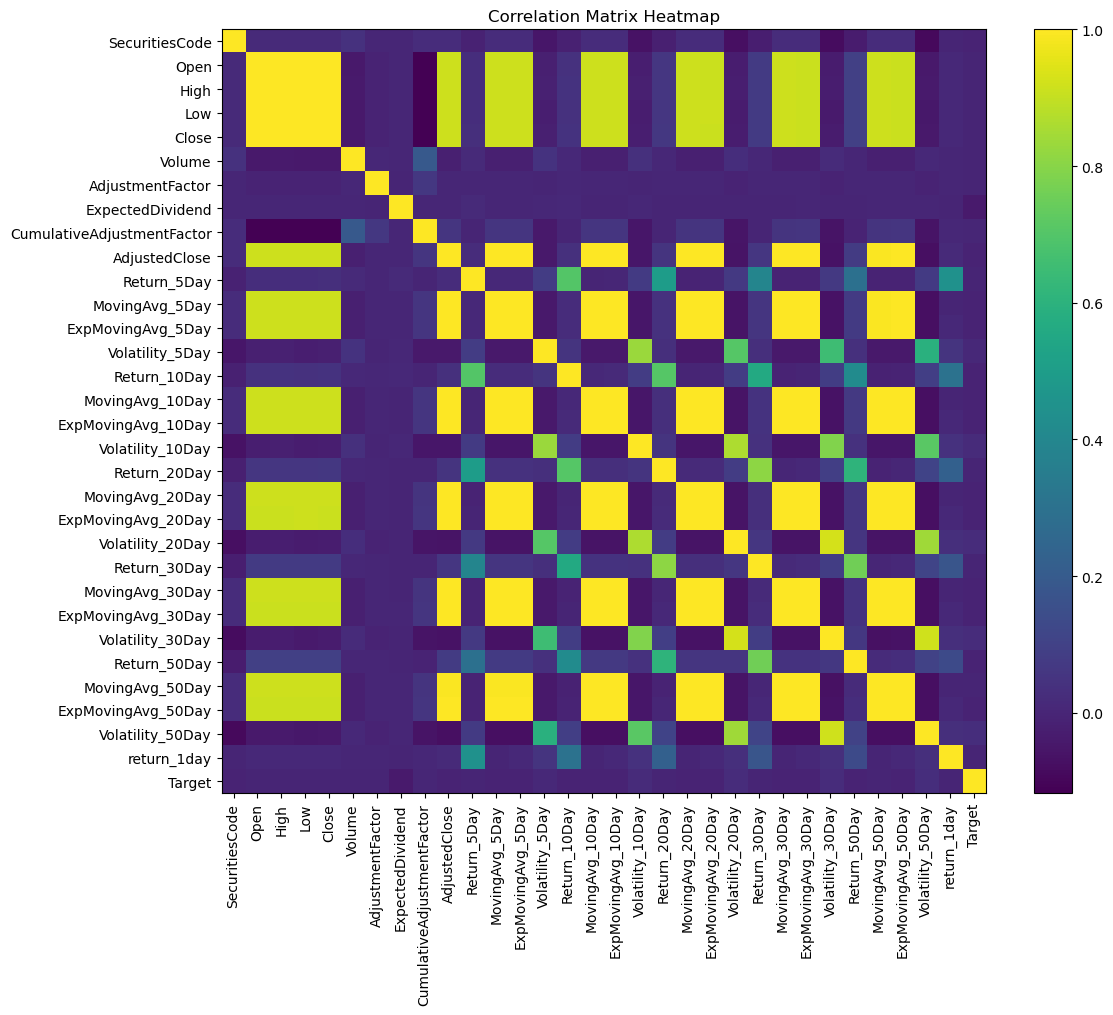

In [5]:
df  = pd.read_csv('..\input\\jpx-tokyo-stock-exchange-prediction\\training_price_features.csv')
df ['Date'] = pd.to_datetime(df ['Date'])
df['return_1day'] = df['AdjustedClose'].pct_change(1)
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Reorder the columns so that "Target" is at the very right (last column)
if "Target" in df_numeric.columns:
    cols = [col for col in df_numeric.columns if col != "Target"] + ["Target"]
    df_numeric = df_numeric[cols]
else:
    print("Warning: 'Target' column not found in numeric columns.")

# Calculate the correlation matrix for all numeric features
corr_matrix = df_numeric.corr()

# Print the correlation between each feature and the Target column
print("Correlation with Target:")
print(corr_matrix['Target'])

# ----------------------------------------
# 1. Visualize the full correlation matrix as a heatmap
# ----------------------------------------
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='viridis', interpolation='none')
plt.colorbar()
plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr_matrix.index)), labels=corr_matrix.index)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()


### Statistics

In [23]:
y = df['Target']
print(len(y))
print(y.max(), y.min(), y.mean(), y.std())

1880531
1.119512195121951 -0.5785413744740533 0.00041717831575911334 0.023731911584742825


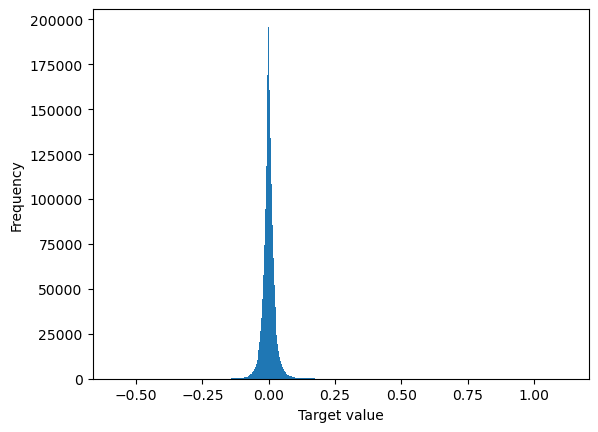

In [24]:
plt.hist(y, bins=500)
plt.ylabel('Frequency')
plt.xlabel('Target value')
plt.show()


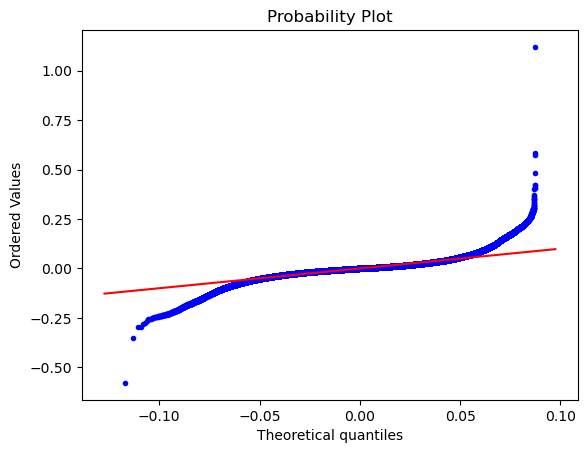

In [26]:
def Q_Q (y):
  mean_y = np.mean(y)
  std_y = np.std(y)
  res, _ = stats.probplot(y, dist="norm", sparams=(mean_y, std_y), plot=plt)
  plt.gca().get_lines()[0].set_markersize(3)
  ax = plt.gca()
  x_vals = np.array(ax.get_xlim())
  plt.plot(x_vals, x_vals, color='red', linestyle='-')
  plt.show()
Q_Q(y)

### OLS

R2 score: 0.002350140867539263


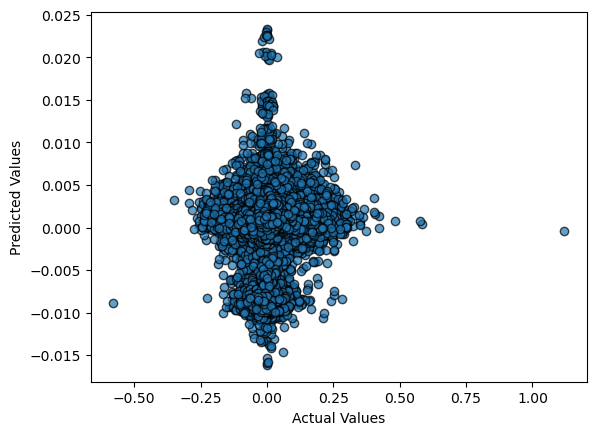

In [35]:
model = LinearRegression()
X = df_numeric.drop(columns=['Target'])
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"R2 score: {r2}")

plt.scatter(y, y_pred, edgecolor='k', alpha=0.7)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.show()